In [ ]:
import os
import sys
import hashlib

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.makedirs("./out", exist_ok=True)
sys.path.append('../../pybind/build')

In [2]:
class KVCache:
    pass

class KVCacheNone(KVCache):
    def __init__(self):
        self.cache = {}
    
    def put(self, layer, idx, key, value):
        self.cache[(layer, idx)] = (key, value)

    def get(self, layer, idx):
        return self.cache.get((layer, idx), None)

In [3]:
class WeightWrapper:
    name = None
    full_name = None
    weight_map = None
    shape = None

def process_weight_none(global_weight_map, weight_name, weight_wrapper, total_layer, cached = False):
    return None

def process_weight_no_transpose(global_weight_map, weight_name, weight_wrapper, total_layer, cached = False):
    weight_wrapper.weight_map = {}
    for l in range(total_layer):
        weight_wrapper.weight_map[l] = global_weight_map[weight_name.format(layer = l)]
        assert weight_wrapper.weight_map[l].shape == weight_wrapper.shape, f"name = {weight_name}, shape = {weight_wrapper.shape}, layer = {l}, shape = {weight_wrapper.weight_map[l].shape}"
    return weight_wrapper

def process_weight_layer(global_weight_map, weight_name, weight_wrapper, total_layer, cached = False):
    weight_wrapper.weight_map = {}
    for l in range(total_layer):
        weight_wrapper.weight_map[l] = global_weight_map[weight_name.format(layer = l)].t()
        assert weight_wrapper.weight_map[l].shape == weight_wrapper.shape, f"name = {weight_name}, shape = {weight_wrapper.shape}, layer = {l}, shape = {weight_wrapper.weight_map[l].shape}"
    return weight_wrapper


In [4]:
from enum import Enum
import numpy as np
import torch
import bind_genEmbedding

class IOBufferType(Enum):
    FULL = 1
    DiscontinousPartition = 2
    ContinousPartition = 3
    PartialSum = 4

class IOBufferTransform(Enum):
    Replicate = 1
    Partition = 2
    Aggregate = 3

class IOWrapper:
    def __init__(self, owner, name, IOtype, dtype=torch.float16):
        self.owner = owner  # owner is now an Operations object or similar
        self.name = name
        self.prev = []
        self.next = []
        self.prev_depend_on_prev_layer = []
        self.shape = None # shape [0] is non-contiguous dimension, shape [1] is contiguous dimension
        self.ptr = 0
        self.IOtype = IOtype
        self.tensor: torch.Tensor = None
        self.child = []
        self.transform = None
        self.tensor_offset = 0
        self.dtype = dtype
        
    
    @property
    def tensor_range(self):
        if self.shape is None:
            return None
        return (self.tensor_offset, self.tensor_offset + self.shape[0])
    
    @property
    def fullName(self):
        owner_name = self.owner.name if hasattr(self.owner, "name") else str(self.owner)
        return f"{owner_name}_{self.name}"
    
    def chain(self, next_wrapper, depend_on_prev=False):
        self.next.append(next_wrapper)
        next_wrapper.prev.append(self)
        next_wrapper.prev_depend_on_prev_layer.append(depend_on_prev)
        # check dtype must be the same
        if self.dtype != next_wrapper.dtype:
            raise Exception(f"Error: {self.fullName} and {next_wrapper.fullName} has different dtype")
        
        return next_wrapper
    
    def __rshift__(self, next_wrapper):
        return self.chain(next_wrapper)
    
    def toStr(self):
        # name, prev = [], next = []
        return f"{self.fullName}, prev = {[p.fullName for p in self.prev]}, next = {[n.fullName for n in self.next]}"
    
    def checkCorrectPartition(self):
        # actually only three case: same io, aggregate, partition. Cannot discontious partition

        # case 1: No next wrapper
        if len(self.next) == 0:
            return True
        
        # pre-check: all next types are the same (differ from self is OK)
        if not (all(n.IOtype == self.next[0].IOtype for n in self.next)):
            print(f"Error: {self.fullName} has different IOtype with its next")
            for wrapper in self.next:
                print(f"  {wrapper.fullName}, IOtype = {wrapper.IOtype}")
            return False
        
        next_type = self.next[0].IOtype
        
        # case 2: same IO type, same size
        if next_type == self.IOtype:
            if all(n.shape == self.shape for n in self.next):
                self.transform = IOBufferTransform.Replicate
                return True
            else:
                print(f"[Replicate Failure] {self.fullName}: Expected shape {self.shape}")
                for n in self.next:
                    print(f"  {n.fullName}, shape = {n.shape}")
                return False

        # case 3: Partition
        if self.IOtype == IOBufferType.FULL and next_type == IOBufferType.ContinousPartition:
            total_rows = sum(n.shape[0] for n in self.next)
            if total_rows == self.shape[0]:
                self.child = self.next
                self.transform = IOBufferTransform.Partition
                return True
            else:
                print(f"[ContinousPartition Failure] {self.fullName}: Sum of partition rows is {total_rows} but expected {self.shape[0]}.")
                for n in self.next:
                    print(f"  {n.fullName}, shape = {n.shape}")
                return False
            
            
        # case 3: aggregate
        if self.IOtype == IOBufferType.ContinousPartition and next_type == IOBufferType.FULL:
            # consider all next wrappers' previous wrappers
            for n in self.next:
                for p in n.prev:
                    if p.IOtype != IOBufferType.ContinousPartition:
                        print(f"[ContinousAggregation Failure] {self.fullName}: Expected all next wrappers' previous wrappers to be ContinousPartition.")
                        return False
                if sum(p.shape[0] for p in n.prev) != n.shape[0]:
                    print(f"[ContinousAggregation Failure] {self.fullName}: Sum of partition rows is {sum(p.shape[0] for p in n.prev)} but expected {n.shape[0]}.")
                    for p in n.prev:
                        print(f"  {p.fullName}, shape = {p.shape}")
                    return False
                n.child = n.prev
            self.transform = IOBufferTransform.Aggregate
            return True
        
        # Fallback: configuration does not match any recognized partition scheme.
        next_types = [n.IOtype for n in self.next]
        next_shapes = [n.shape for n in self.next]
        print(f"[Partition Check Failure] {self.fullName}: Unrecognized partition configuration.")
        print(f"Self IOtype: {self.IOtype}, shape: {self.shape}")
        print(f"Next partitions IOtypes: {next_types}")
        print(f"Next partitions shapes: {next_shapes}")
        return False

class Operations:
    def __init__(self, name):
        self.inputs = {}
        self.outputs = {}
        self.weights = {}
        self.externals = {}
        self.name = name
        self.first_layer_only = False
        self.last_layer_only = False
        self.weight_name = None
    
    @property
    def prerequisites(self):
        dep = []
        for _, input_wrapper in self.inputs.items():
            for dep_wrapper, prev_layer in zip(input_wrapper.prev, input_wrapper.prev_depend_on_prev_layer):
                dep.append((dep_wrapper.owner, prev_layer))
        
        return dep
        
    def checkConnection(self):
        for name, IOwrapper in self.inputs.items():
            if IOwrapper.prev is None:
                raise Exception(f"Operation {self.name}, Input {name} is not connected")
    
    def setWeightName(self, name):
        self.weight_name = name
        return self
    
    def processWeight(self, global_weight_map, total_layers, cached = False):
        return process_weight_none(global_weight_map, self.weight_name, None, total_layers, cached)
    
    def first_only(self):
        self.first_layer_only = True
        return self
    
    def last_only(self):
        self.last_layer_only = True
        return self
    
    def __str__(self):
        return self.name    

# -------------------------------------------------------------------
# Operations definitions (ordered loosely by type)

class GlobalInput(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {}
        self.outputs = {
            "tokens": IOWrapper(self, 'tokens', IOBufferType.FULL, dtype=torch.int32)
        }
    
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.outputs["tokens"].shape = (self.batch_size,)
    
    def run(self, layer):
        pass

class GenEmbedding(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "token": IOWrapper(self, 'token', IOBufferType.FULL, dtype=torch.int32),
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.FULL)
        }
        self.weights = {
            "embedding": WeightWrapper()
        }
    
    def setShape(self, hidden_dim, vocab_size):
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        self.weights["embedding"].shape = (vocab_size, hidden_dim)
    
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["token"].shape = (self.batch_size,)
        self.outputs["output"].shape = (self.batch_size, self.hidden_dim)
        
    def run(self, layer):
        # Retrieve token indices from input and the embedding matrix from weight_map.
        tokens = self.inputs["token"].tensor  # expected shape: (1, batch_size)
        print(self.inputs["token"].tensor.device)
        embedding = self.weights["embedding"].weight_map[layer]  # expected shape: (vocab_size, hidden_dim)
        print(embedding[tokens])
        # create a new tensor to store the output
        output_temp = torch.zeros((self.batch_size, self.hidden_dim), dtype=torch.float16, device=self.inputs["token"].tensor.device)
        bind_genEmbedding.genEmbedding(tokens, embedding, output_temp)

        # self.outputs["output"].tensor.copy_(embedding[tokens])
        self.outputs["output"].tensor.copy_(output_temp)
    
    def processWeight(self, global_weight_map, total_layers, cached = False):
        return process_weight_no_transpose(global_weight_map, self.weight_name, self.weights["embedding"], total_layers, cached)
    
class LayerNorm(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "input": IOWrapper(self, 'input', IOBufferType.FULL),
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.FULL)
        }
        self.weights = {
            "weight": WeightWrapper(),
        }
    
    def setShape(self, hidden_dim):
        self.hidden_dim = hidden_dim
        self.weights["weight"].shape = (self.hidden_dim,)
    
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["input"].shape = (self.batch_size, self.hidden_dim)
        self.outputs["output"].shape = (self.batch_size, self.hidden_dim)
        
    def run(self, layer):
        x = self.inputs["input"].tensor
        x = x.to(torch.float32)
        epsilon = 1e-5
        # Compute the root-mean-square (RMS) along the last dimension.
        rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + epsilon)
        normalized_x = x / rms
        weight_val = self.weights["weight"].weight_map[layer]
        # Scale the normalized values by the learned weight.
        self.outputs["output"].tensor.copy_(normalized_x.to(torch.float16) * weight_val)
    
    def processWeight(self, global_weight_map, total_layers, cached = False):
        return process_weight_layer(global_weight_map, self.weight_name, self.weights["weight"], total_layers, cached)
        

class GEMMNoBias(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "A": IOWrapper(self, 'A', IOBufferType.FULL),
        }
        self.outputs = {
            "D": IOWrapper(self, 'D', IOBufferType.FULL)
        }
        self.weights = {
            "B": WeightWrapper()
        }
    
    def setShape(self, N, K):
        self.N = N
        self.K = K        
        self.weights["B"].shape = (self.K, self.N)
    
    def setBatchSize(self, M):
        self.M = M
        self.inputs["A"].shape = (self.M, self.K)
        self.outputs["D"].shape = (self.M, self.N)

        
    def run(self, layer):
        A = self.inputs["A"].tensor
        B = self.weights["B"].weight_map[layer]
        self.outputs["D"].tensor.copy_(A.matmul(B))
    
    def processWeight(self, global_weight_map, total_layers, cached = False):
        return process_weight_layer(global_weight_map, self.weight_name, self.weights["B"], total_layers, cached)

class GEMMCombineWeight(GEMMNoBias):
    def setWeightName(self, name_list):
        self.weight_name = name_list
        return self
    
    def processWeight(self, global_weight_map, total_layers, cached=False):
        self.weights["B"].weight_map = {}
        for l in range(total_layers):
            self.weights["B"].weight_map[l] = torch.cat([global_weight_map[name.format(layer=l)].t() for name in self.weight_name], dim=1).contiguous()

import math
import torch

# (Assume that the following classes and enums are defined somewhere in your framework.)
# from your_framework import Operations, IOWrapper, IOBufferType

class RopeAppend(Operations):
    def __init__(
        self,
        name,
        rope_type="llama3",
        theta=10000.0,
        factor=8.0,
        low_freq_factor=1.0,
        high_freq_factor=4.0,
        original_max_position_embeddings=8192,
    ):
        """
        Args:
            name (str): The name of this operator.
            rope_type (str): The type of RoPE implementation to use. For llama3, pass "llama3".
            theta (float): The base used to compute the inverse frequency (typically set from config.rope_theta).
            factor (float): Scaling factor used in llama3.
            low_freq_factor (float): Lower bound frequency factor (llama3).
            high_freq_factor (float): Upper bound frequency factor (llama3).
            original_max_position_embeddings (int): The original maximum context length used in pretraining.
        """
        super().__init__(name)
        self.inputs = {"kqv": IOWrapper(self, "kqv", IOBufferType.FULL)}
        self.outputs = {"q": IOWrapper(self, "q", IOBufferType.FULL)}
        self.externals = {"KVCache": None}
        
        # Save RoPE configuration.
        self.rope_type = rope_type
        self.theta = theta  # typically config.rope_theta
        self.factor = factor
        self.low_freq_factor = low_freq_factor
        self.high_freq_factor = high_freq_factor
        self.original_max_position_embeddings = original_max_position_embeddings

    def setShape(self, num_kv_heads, num_qo_heads, head_dim):
        self.num_kv_heads = num_kv_heads
        self.num_qo_heads = num_qo_heads
        self.head_dim = head_dim

    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        # The input tensor "kqv" is assumed to have a flattened layout:
        # [batch_size, (num_qo_heads + 2 * num_kv_heads) * head_dim]
        self.inputs["kqv"].shape = (
            self.batch_size,
            (self.num_qo_heads + 2 * self.num_kv_heads) * self.head_dim,
        )
        # The output "q" has shape [batch_size, num_qo_heads * head_dim]
        self.outputs["q"].shape = (self.batch_size, self.num_qo_heads * self.head_dim)

    def update(self, qo_indicies):
        """Stores the starting indices for the query/key segments."""
        self.qo_indicies = qo_indicies

    def rotate_half(self, x):
        """Rotates the last half of the last dimension."""
        dim = x.shape[-1]
        x1 = x[..., : dim // 2]
        x2 = x[..., dim // 2 :]
        return torch.cat([-x2, x1], dim=-1)

    def apply_rope(self, x, offset=0):
        """
        Applies RoPE to the tensor `x` (of shape [seq_len, head_dim]). For llama3,
        we adjust the inverse frequency vector as described in the paper.
        
        Args:
            x (torch.Tensor): Input tensor with shape [seq_len, head_dim].
            offset (int): The starting position offset.
        
        Returns:
            torch.Tensor: The rotated tensor.
        """
        seq_len, dim = x.shape
        device = x.device
        dtype = x.dtype
        positions = torch.arange(offset, offset + seq_len, device=device, dtype=dtype)

        if self.rope_type == "llama3.1":
            # Compute the basic inverse frequency vector using theta.
            inv_freq = 1.0 / (
                self.theta ** (torch.arange(0, dim, 2, device=device, dtype=dtype) / dim)
            )
            # Compute the wavelengths.
            wavelen = 2 * math.pi / inv_freq
            low_freq_wavelen = self.original_max_position_embeddings / self.low_freq_factor
            high_freq_wavelen = self.original_max_position_embeddings / self.high_freq_factor

            # For frequencies with wavelengths greater than the low bound, divide inv_freq by factor.
            inv_freq_llama = torch.where(wavelen > low_freq_wavelen, inv_freq / self.factor, inv_freq)

            # For values in between, interpolate smoothly.
            smooth_factor = (self.original_max_position_embeddings / wavelen - self.low_freq_factor) / (
                self.high_freq_factor - self.low_freq_factor
            )
            smoothed_inv_freq = (1 - smooth_factor) * (inv_freq_llama / self.factor) + smooth_factor * inv_freq_llama

            # Identify indices where wavelengths are in the medium range.
            is_medium_freq = (wavelen >= high_freq_wavelen) & (wavelen <= low_freq_wavelen)
            inv_freq_final = torch.where(is_medium_freq, smoothed_inv_freq, inv_freq_llama)
        elif self.rope_type == "llama3":
            base = 500000.0
            dim = 128
            inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2, dtype=torch.int64).float().to(device) / dim))
            # print("inv_freq:", inv_freq)
            inv_freq_expanded = inv_freq[None, :, None].float().expand(1, -1, 1)
            position_ids_expanded = positions[None, None, :].float()
            with torch.autocast(device_type=device.type, enabled=False):
                freqs = (inv_freq_expanded.float() @ position_ids_expanded.float()).transpose(1, 2)
                emb = torch.cat((freqs, freqs), dim=-1)
                cos = emb.cos()
                sin = emb.sin()
            cos = cos.unsqueeze(1)
            sin = sin.unsqueeze(1)

            x = x.reshape(1, 7, -1, 128).transpose(1, 2)
            print("x shape:", x.shape)
            print("cos shape:", cos.shape)
            x = x * cos + self.rotate_half(x) * sin
            return x.transpose(1, 2).reshape(positions.shape[0], -1).to(dtype=dtype)
            
        else:
            # Default RoPE: simply use the base theta.
            inv_freq_final = 1.0 / (
                self.theta ** (torch.arange(0, dim, 2, device=device, dtype=dtype) / dim)
            )

        # Compute the sinusoidal inputs.
        
        sinusoid_inp = torch.einsum("i,j->ij", positions, inv_freq_final)
        sin = sinusoid_inp.sin()
        cos = sinusoid_inp.cos()

        # Expand sin and cos to match x's dimension.
        sin = torch.repeat_interleave(sin, repeats=2, dim=-1)
        cos = torch.repeat_interleave(cos, repeats=2, dim=-1)

        # Apply the RoPE transformation.
        return x * cos + self.rotate_half(x) * sin

    def run(self, layer):
        """
        The run method splits the input `kqv` tensor into key, query, and value tensors,
        applies RoPE (using the llama3 variant if selected) to the query and key portions,
        and writes the updated keys to an external KV cache. The output "q" is set as a copy of v.
        """
        kqv = self.inputs["kqv"].tensor
        # Determine the number of elements for each slice.
        layout_strides = [
            self.num_qo_heads * self.head_dim,
            self.num_kv_heads * self.head_dim,
            self.num_kv_heads * self.head_dim,
        ]
        # Split kqv into key, query, and value (here assumed to be in the order: k, q, v).
        q, k, v = torch.split(kqv, layout_strides, dim=1)
        k = k.contiguous()
        v = v.contiguous()
        q = q.contiguous()
        # print shapes of k, q, v
        print(f"Layer {layer}: k shape: {k.shape}, q shape: {q.shape}, v shape: {v.shape}")
        

        # Process each batch element.
        for i in range(len(self.qo_indicies) - 1):
            start = self.qo_indicies[i]
            end = self.qo_indicies[i + 1]
            sub_q = q[start:end, :]
            sub_k = k[start:end, :]

            # Apply RoPE to both the query and key sub-tensors.
            sub_q = self.apply_rope(sub_q, offset=0)
            sub_k = self.apply_rope(sub_k, offset=0)

            # Write the updated values back.
            q[start:end, :] = sub_q
            k[start:end, :] = sub_k

            # Update the external KVCache with the new key and value.
            self.externals["KVCache"].put(layer, i, sub_k, v[start:end, :])

        self.outputs["q"].tensor.copy_(q)

    
class DecAttn(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "Q": IOWrapper(self, 'Q', IOBufferType.ContinousPartition),
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.ContinousPartition)
        }
        self.externals = {
            "KVCache": None
        }
    
    def setShape(self, num_kv_heads, num_qo_heads, head_dim):
        self.num_kv_heads = num_kv_heads
        self.num_qo_heads = num_qo_heads
        self.head_dim = head_dim
        self.q_dim = num_qo_heads * head_dim
        
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["Q"].shape = (self.batch_size, self.q_dim)
        self.outputs["output"].shape = (self.batch_size, self.q_dim)
    
    def update(self, qo_indicies):
        self.qo_indicies = qo_indicies
    
    def run(self, layer):
        # Q = self.inputs["Q"].tensor
        # KVdata = self.externals["KVdata"].tensor
        # # Q: (batch_size, q_dim), KVdata: (batch_size, 2 * num_kv_heads * head_dim)
        # # output: (batch_size, q_dim)
        # self.outputs["output"].tensor = Q @ KVdata.T
        pass
    
class PFAttn(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "Q": IOWrapper(self, 'Q', IOBufferType.ContinousPartition),
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.ContinousPartition)
        }
        # Note: for consistency with other operators (like RopeAppend), we expect the external KV cache to be
        # available as "KVCache". If needed, you can change the key name.
        self.externals = {
            "KVCache": None
        }
    
    def setShape(self, num_kv_heads, num_qo_heads, head_dim):
        self.num_kv_heads = num_kv_heads
        self.num_qo_heads = num_qo_heads
        self.head_dim = head_dim
        self.q_dim = num_qo_heads * head_dim
    
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["Q"].shape = (self.batch_size, self.q_dim)
        self.outputs["output"].shape = (self.batch_size, self.q_dim)
    
    def update(self, qo_indicies):
        """Stores the query offset indices for each batch element.  
        qo_indicies should be a list (or tensor) of length (batch_size + 1) such that for each batch index i,  
        the query slice is Q[qo_indicies[i]:qo_indicies[i+1], :].
        """
        self.qo_indicies = qo_indicies
    
    def run(self, layer):
        """
        For each batch element, this method retrieves the query portion (Q) of shape
        [n_q, num_qo_heads * head_dim] and then uses the external KV cache to get the stored keys and values.
        
        The attention operation is performed per head as follows:
        1. Reshape the query tensor to [n_q, num_qo_heads, head_dim].
        2. Retrieve the cached keys and values (sub_k and sub_v) and reshape them to
            [n_k, num_kv_heads, head_dim] (where n_k is the number of cached keys).
        3. Compute the group size as: group_size = num_qo_heads // num_kv_heads.
            This tells you how many query heads correspond to each key/value head.
        4. Expand (repeat) the key and value tensors along the head dimension so that each query head
            has a corresponding key and value (i.e. each key/value head is repeated group_size times).
        5. Compute attention scores for each head via dot-product scaling (using the factor 1/sqrt(head_dim)).
        6. **Apply a causal mask over the scores** so that each query position can only attend to
            allowed keys (i.e. those coming from the past or up to the current position among the new tokens).
        7. Apply softmax over the key dimension to obtain attention weights.
        8. Use the attention weights to compute a weighted sum over the value vectors.
        9. Flatten the output back to shape [n_q, num_qo_heads * head_dim] and write it to the output.
        
        The final output is written to self.outputs["output"].tensor.
        """
        Q = self.inputs["Q"].tensor
        scale = 1.0 / (self.head_dim ** 0.5)
        # Compute group size: how many query heads correspond to one key/value head.
        group_size = self.num_qo_heads // self.num_kv_heads

        for i in range(len(self.qo_indicies) - 1):
            # Retrieve the query slice for this batch element.
            start = self.qo_indicies[i]
            end = self.qo_indicies[i + 1]
            # Q is expected to be flattened as [n_total, num_qo_heads * head_dim];
            # extract the sub-tensor corresponding to this batch element.
            sub_q = Q[start:end, :]  # shape: [n_q, num_qo_heads * head_dim]
            # Reshape queries into separate heads.
            # New shape: [n_q, num_qo_heads, head_dim]
            sub_q = sub_q.view(-1, self.num_qo_heads, self.head_dim)
            
            # Retrieve cached keys and values from the external KV cache.
            # Expected shapes:
            #   sub_k: [n_k, num_kv_heads * head_dim]
            #   sub_v: [n_k, num_kv_heads * head_dim]
            sub_k, sub_v = self.externals["KVCache"].get(layer, i)
            n_k = sub_k.shape[0]
            # Reshape keys and values so that the head dimension is explicit.
            # New shapes: [n_k, num_kv_heads, head_dim]
            sub_k = sub_k.view(n_k, self.num_kv_heads, self.head_dim)
            sub_v = sub_v.view(n_k, self.num_kv_heads, self.head_dim)
            
            # Expand (repeat) the keys and values so that they align with the query heads.
            # Each key/value head is repeated group_size times.
            # New shapes after repeat: [n_k, num_qo_heads, head_dim]
            expanded_k = sub_k.repeat_interleave(group_size, dim=1)
            expanded_v = sub_v.repeat_interleave(group_size, dim=1)
            
            # Compute attention scores.
            # Use Einstein summation notation: for each query (q) and head (h), compute dot product with each key (k)
            # resulting in scores of shape: [n_q, num_qo_heads, n_k]
            scores = torch.einsum("qhd,khd->qhk", sub_q, expanded_k) * scale
            
            # -------------------------------
            # Add Causal Mask to Attention
            # -------------------------------
            # Determine the number of query tokens.
            n_q = sub_q.shape[0]
            # Assume that the KV cache has 'past' tokens (from previous timesteps) and new tokens,
            # so that n_k = past_length + n_q.
            past_length = max(n_k - n_q, 0)
            
            if past_length > 0:
                # For the new tokens (the last n_q keys), build a lower-triangular mask.
                # For each query position i (0-indexed among the new tokens), allow attending only
                # to new keys with positions <= i.
                new_mask = torch.tril(torch.ones(n_q, n_q, dtype=torch.bool, device=scores.device))
                # For the past tokens (first past_length keys), we allow full attention.
                past_mask = torch.ones(n_q, past_length, dtype=torch.bool, device=scores.device)
                # Concatenate the masks along the key dimension.
                causal_mask = torch.cat([past_mask, new_mask], dim=1)  # shape: [n_q, n_k]
            else:
                # If there is no past context (i.e. n_k == n_q), use a standard lower-triangular mask.
                causal_mask = torch.tril(torch.ones(n_q, n_k, dtype=torch.bool, device=scores.device))
            
            # Expand the causal mask to match the scores' shape: [n_q, num_qo_heads, n_k].
            # Then mask out disallowed (future) positions by setting them to -inf.
            scores = scores.masked_fill(~causal_mask.unsqueeze(1), float("-inf"))
            
            # Apply softmax over the key dimension.
            attn_weights = torch.softmax(scores, dim=-1)
            
            # Compute attention output as the weighted sum over the value vectors.
            # Resulting shape: [n_q, num_qo_heads, head_dim]
            out = torch.einsum("qhk,khd->qhd", attn_weights, expanded_v)
            # Flatten heads back to shape: [n_q, num_qo_heads * head_dim]
            out = out.reshape(-1, self.num_qo_heads * self.head_dim)
            # Write the computed output into the operator's output tensor.
            self.outputs["output"].tensor[start:end, :].copy_(out)



class GEMM(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "A": IOWrapper(self, 'A', IOBufferType.FULL),
            "C": IOWrapper(self, 'C', IOBufferType.FULL)
        }
        self.outputs = {
            "D": IOWrapper(self, 'D', IOBufferType.FULL)
        }
        self.weights = {
            "B": WeightWrapper()
        }
        
    def setShape(self, N, K):
        self.N = N
        self.K = K
        self.weights["B"].shape = (self.K, self.N)
    
    def setBatchSize(self, M):
        self.M = M
        self.inputs["A"].shape = (self.M, self.K)
        self.inputs["C"].shape = (self.M, self.N)
        self.outputs["D"].shape = (self.M, self.N)
        
    
    def run(self, layer):
        A = self.inputs["A"].tensor
        C = self.inputs["C"].tensor
        B = self.weights["B"].weight_map[layer]
        self.outputs["D"].tensor.copy_(A.matmul(B) + C)
    
    def processWeight(self, global_weight_map, total_layers, cached = False):
        return process_weight_layer(global_weight_map, self.weight_name, self.weights["B"], total_layers, cached)

class Activation(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "input": IOWrapper(self, 'input', IOBufferType.FULL),
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.FULL)
        }
        self.act_fn = torch.nn.SiLU()
        
    def setShape(self, N):
        self.N = N
    
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["input"].shape = (self.batch_size, self.N * 2)
        self.outputs["output"].shape = (self.batch_size, self.N)
        
    def run(self, layer):
        x = self.inputs["input"].tensor
        # Split the input along the last dimension.
        A, B = torch.split(x, self.N, dim=-1)
        self.outputs["output"].tensor.copy_(A * self.act_fn(B))

class Sampling(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "logits": IOWrapper(self, 'logits', IOBufferType.FULL)
        }
        self.outputs = {
            "tokens": IOWrapper(self, 'tokens', IOBufferType.FULL, dtype=torch.int32)
        }
    
    def setShape(self, vocab_size):
        self.vocab_size = vocab_size
        
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["logits"].shape = (self.batch_size, self.vocab_size)
        self.outputs["tokens"].shape = (self.batch_size,)
        
    def run(self, layer):
        logits = self.inputs["logits"].tensor
        tokens = torch.argmax(logits, dim=1)
        self.outputs["tokens"].tensor.copy_(tokens)

class GlobalOutput(Operations):
    def __init__(self, name):
        super().__init__(name)
        self.inputs = {
            "tokens": IOWrapper(self, 'tokens', IOBufferType.FULL, dtype=torch.int32)
        }
        self.outputs = {}
    
    def setBatchSize(self, batch_size):
        self.batch_size = batch_size
        self.inputs["tokens"].shape = (self.batch_size,)

    def run(self, layer):
        pass

In [5]:
import matplotlib.pyplot as plt
import math
import matplotlib.patches as patches
import networkx as nx
def draw_graphs_subplots(graphs, title_prefix):
    """Draw each graph from a list of NetworkX graphs on subplots with bounding boxes."""
    num_graphs = len(graphs)
    cols = math.ceil(math.sqrt(num_graphs))
    rows = math.ceil(num_graphs / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    
    # Flatten axes so we can index by a single index.
    if num_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, graph in enumerate(graphs):
        ax = axes[i]
        ax.set_title(f"{title_prefix} {i}")
        pos = nx.spring_layout(graph)
        nx.draw(graph, pos, with_labels=True, font_weight='bold', ax=ax)
        # Compute bounding box based on node positions.
        x_vals = [p[0] for p in pos.values()]
        y_vals = [p[1] for p in pos.values()]
        if x_vals and y_vals:
            x_min, x_max = min(x_vals), max(x_vals)
            y_min, y_max = min(y_vals), max(y_vals)
            margin_x = 0.1 * (x_max - x_min) if (x_max - x_min) != 0 else 0.1
            margin_y = 0.1 * (y_max - y_min) if (y_max - y_min) != 0 else 0.1
            rect = patches.Rectangle(
                (x_min - margin_x, y_min - margin_y),
                (x_max - x_min) + 2 * margin_x,
                (y_max - y_min) + 2 * margin_y,
                edgecolor='red',
                facecolor='none',
                lw=2
            )
            ax.add_patch(rect)

    # Turn off unused axes.
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()
def plot_graph_topological(G):
    # Compute the topological order
    topological_order = list(nx.topological_sort(G))
    
    # Assign x-coordinates based on topological depth
    depth_map = {}
    for node in topological_order:
        depth_map[node] = max((depth_map.get(pred, -1) for pred in G.predecessors(node)), default=-1) + 1
    
    # Group nodes by depth
    depth_levels = {}
    for node, depth in depth_map.items():
        depth_levels.setdefault(depth, []).append(node)
    
    max_depth = max(depth_map.values())
    
    # Assign positions
    pos = {}
    max_node_at_depth = max(len(nodes) for nodes in depth_levels.values())
    for depth, nodes in depth_levels.items():
        y_offset = -(len(nodes) - 1) / 2  # Center nodes vertically
        for i, node in enumerate(nodes):
            pos[node] = (depth, y_offset + i)
    
    # Create label positions by shifting each label upward
    label_pos = {node: (x, y + 0.2 * (-1)**(x)) for node, (x, y) in pos.items()}
    
    # set y limit to be 1.2x the number of nodes
    
    # Plot the graph
    plt.figure(figsize=( 5 + 1 * max_depth, 2 + max_node_at_depth))
    nx.draw(
        G, pos, with_labels=False, node_size=1000, node_color="skyblue", font_size=10, font_color="black"
    )
    plt.ylim(-max_node_at_depth*0.6, max_node_at_depth * 0.6)
    nx.draw_networkx_labels(G, label_pos, font_size=10, font_color="black")
    plt.title("Graph Layout by Topological Depth", fontsize=16)
    plt.show()
    


In [6]:
import torch
class BufferAllocator():
    def __init__(self, buffers_list):
        self.buffers_list = buffers_list
        self.alloc_nodes = {}
        self.allocation_graph = []
        self.total_allocated = 0

    def check_buffer_name_and_size(self):
        # Assert fullName is unique.
        fullName_list = [wrapper.fullName for wrapper in self.buffers_list]
        assert len(fullName_list) == len(set(fullName_list))

        for wrapper in self.buffers_list:
            assert wrapper.shape is not None, f"{wrapper.fullName} has no shape"
            wrapper.checkCorrectPartition()
    
    def create_dependency_graph(self):
        # Build full graph G.
        G = nx.DiGraph()
        for wrapper in self.buffers_list:
            G.add_node(wrapper.fullName, wrapper=wrapper)
        for wrapper in self.buffers_list:
            for next_wrapper in wrapper.next:
                G.add_edge(wrapper.fullName, next_wrapper.fullName)
        self.full_graph = G

    def draw_dependency_graph(self):
        # Draw full graph.
        plot_graph_topological(self.full_graph)
        plt.show()

    def get_connected_components(self):
        # Get connected components.
        components = list(nx.weakly_connected_components(self.full_graph))
        return components
    
    def draw_dependency_subgraphs(self):
        # Build list of subgraphs from G.
        G_subgraphs = [self.full_graph.subgraph(comp) for comp in self.get_connected_components()]
        draw_graphs_subplots(G_subgraphs, title_prefix="Buffer")

    def create_allocation_graph_from_component(self):
        components = self.get_connected_components()
        for component in components:
            wrappers = [self.full_graph.nodes[name]['wrapper'] for name in component]
            G_H = nx.DiGraph()
            for wrapper in wrappers:
                G_H.add_node(wrapper.fullName, wrapper=wrapper)
            # Use 'child' attribute to get connections.
            # If child does not exist, adjust to the correct attribute.
            for wrapper in wrappers:
                for child in wrapper.child:
                    G_H.add_edge(wrapper.fullName, child.fullName)
            
            # find all the nodes that have no incoming edges
            semi_root_nodes = [G_H.nodes[node]['wrapper'] for node in G_H.nodes if G_H.in_degree(node) == 0]
            # create a new node 
            alloc_node = IOWrapper("Alloc", semi_root_nodes[0].fullName, IOBufferType.FULL, dtype=semi_root_nodes[0].dtype)
            alloc_node.shape = semi_root_nodes[0].shape
            alloc_node.child = semi_root_nodes
                
            self.alloc_nodes[frozenset(component)] = alloc_node
            
            # # also add the new node to the graph
            G_H.add_node(alloc_node.fullName, wrapper=alloc_node)
            for node in semi_root_nodes:
                G_H.add_edge(alloc_node.fullName, node.fullName)
            self.allocation_graph.append(G_H)
    
    def draw_allocation_subgraphs(self):
        draw_graphs_subplots(self.allocation_graph, title_prefix="Allocation")
    
    def allocate_buffers_for_components(self):
        self.total_allocated = 0
        for comp, alloc_node in self.alloc_nodes.items():
            shape = alloc_node.shape
            tensor = torch.empty(shape, dtype=alloc_node.dtype, device='cuda')
            self.total_allocated += tensor.numel() * tensor.element_size()
            alloc_node.tensor = tensor
            for semi_root in alloc_node.child:
                semi_root.tensor = tensor
                assert semi_root.shape == shape, f"shape mismatch: {semi_root.fullName} {semi_root.shape} vs {shape}"
                # if have child then further propagate
                if semi_root.child:
                    size_for_child = [child.shape[0] for child in semi_root.child]
                    assert sum(size_for_child) == shape[0], f"shape mismatch: {semi_root.fullName} {size_for_child} vs {shape}"
                    tensor_split_list = tensor.split(size_for_child, dim=0)
                    for idx, child, tensor_split in zip(range(len(semi_root.child)), semi_root.child, tensor_split_list):
                        child.tensor = tensor_split
                        child.tensor_offset = sum(size_for_child[:idx])
                        assert child.shape == tensor_split.shape, f"shape mismatch: {child.fullName} {child.shape} vs {tensor_split.shape}"
    
    def allocate_buffer(self, plot = False):
        self.check_buffer_name_and_size()
        self.create_dependency_graph()
        self.create_allocation_graph_from_component()
        self.allocate_buffers_for_components()
        if plot:
            self.draw_dependency_graph()
            self.draw_dependency_subgraphs()
            self.draw_allocation_subgraphs()
        return self.total_allocated

In [7]:
class Executor():
    def __init__(self, operations_list, layer):
        self.operations_list = operations_list
        self.layer = layer
        self.ordered_operations = []
    
    def not_this_layer(self, op, layer):
        return (op.first_layer_only and layer != 0) or (op.last_layer_only and layer != self.layer - 1)
    
    def plan_layer_ordering(self):
        G = nx.DiGraph()
        for op in self.operations_list:
            for l in range(self.layer):
                if (not l == 0 and op.first_layer_only) or (not l == self.layer - 1 and op.last_layer_only):
                    continue
                G.add_node(f"{op.name}_{l}", op=op, layer=l)
        for op in self.operations_list:
            for i in range(self.layer):
                if (self.not_this_layer(op, i)):
                        continue
                for dep, dep_on_prev_layer in op.prerequisites:
                    if (self.not_this_layer(dep, i)):
                        continue
                    if dep_on_prev_layer:
                        if i > 0:
                            G.add_edge(f"{dep.name}_{i - 1}", f"{op.name}_{i}")
                    else:
                        G.add_edge(f"{dep.name}_{i}", f"{op.name}_{i}")
        self.ordered_operations = list(nx.topological_sort(G))
        self.ordered_graph = G
    
    def draw_ordered_graph(self):
        plot_graph_topological(self.ordered_graph)
    
    def execute(self, weight_map):
        for op_name in self.ordered_operations:
            op, layer = self.ordered_graph.nodes[op_name]['op'], self.ordered_graph.nodes[op_name]['layer']
            op.run(layer)
    
    def print_debug(self, filename="out.txt"):
        file = f"{filename}"

        with open(file, "w") as f:
            for op_name in self.ordered_operations:
                op, layer = self.ordered_graph.nodes[op_name]['op'], self.ordered_graph.nodes[op_name]['layer']
                print(f"{op.name}_{layer}")

                for inputs in op.inputs.values():

                    f.write(f"[{op.name}_{layer}_{inputs.name}]\n")
                    f.write(str(inputs.tensor))
                    f.write("\n")
                    f.write(str(inputs.tensor.shape))
                    f.write("\n")
                    torch.save(inputs.tensor.cpu(), f"./out/{op.name}_{layer}_{inputs.name}")
                    

                for weights in op.weights.values():
                    f.write(f"[{op.name}_{layer}_{weights.name}]\n")
                    f.write(str(weights.weight_map[layer]))
                    f.write("\n")
                    f.write(str(weights.weight_map[layer].shape))
                    f.write("\n")
                    torch.save(weights.weight_map[layer].cpu(), f"./out/{op.name}_{layer}_{weights.name}")

                f.flush()

                op.run(layer)  # Execute the operation

                for outputs in op.outputs.values():
                    f.write(f"[{op.name}_{layer}_{outputs.name}]\n")
                    # f_output.write(str(outputs.tensor))  # Binary as hex
                    f.write(str(outputs.tensor))
                    f.write("\n")
                    f.write(str(outputs.tensor.shape))
                    f.write("\n")
                    torch.save(outputs.tensor.cpu(), f"./out/{op.name}_{layer}_{outputs.name}")

                f.flush()
            f.close()
                    

In [8]:
import tqdm
import os
import safetensors
class WeightManager():
    def load_tensors(tensor_path):
        original_tensors ={}
        for file in tqdm.tqdm(os.listdir(tensor_path)):
            if file.endswith(".safetensors"):
                tensors = safetensors.safe_open(os.path.join(tensor_path, file), 'pt')
                for name in tensors.keys():
                    tensor = tensors.get_tensor(name)
                    original_tensors[name] = tensor
        return original_tensors


    def __init__(self):
        pass
    
    def load_from_safe_tensor(self, tensor_path):
        self.weight_map = WeightManager.load_tensors(tensor_path)
        # make all the tensor fp16
        for key in self.weight_map.keys():
            self.weight_map[key] = self.weight_map[key].half().to('cuda')
    
    def set_weight(self, operation_list, total_layers):
        for op in operation_list:
            op.processWeight(self.weight_map, total_layers)


[[128000, 13347, 11, 889, 527, 499, 30]]


100%|██████████| 10/10 [00:00<00:00, 1187.55it/s]


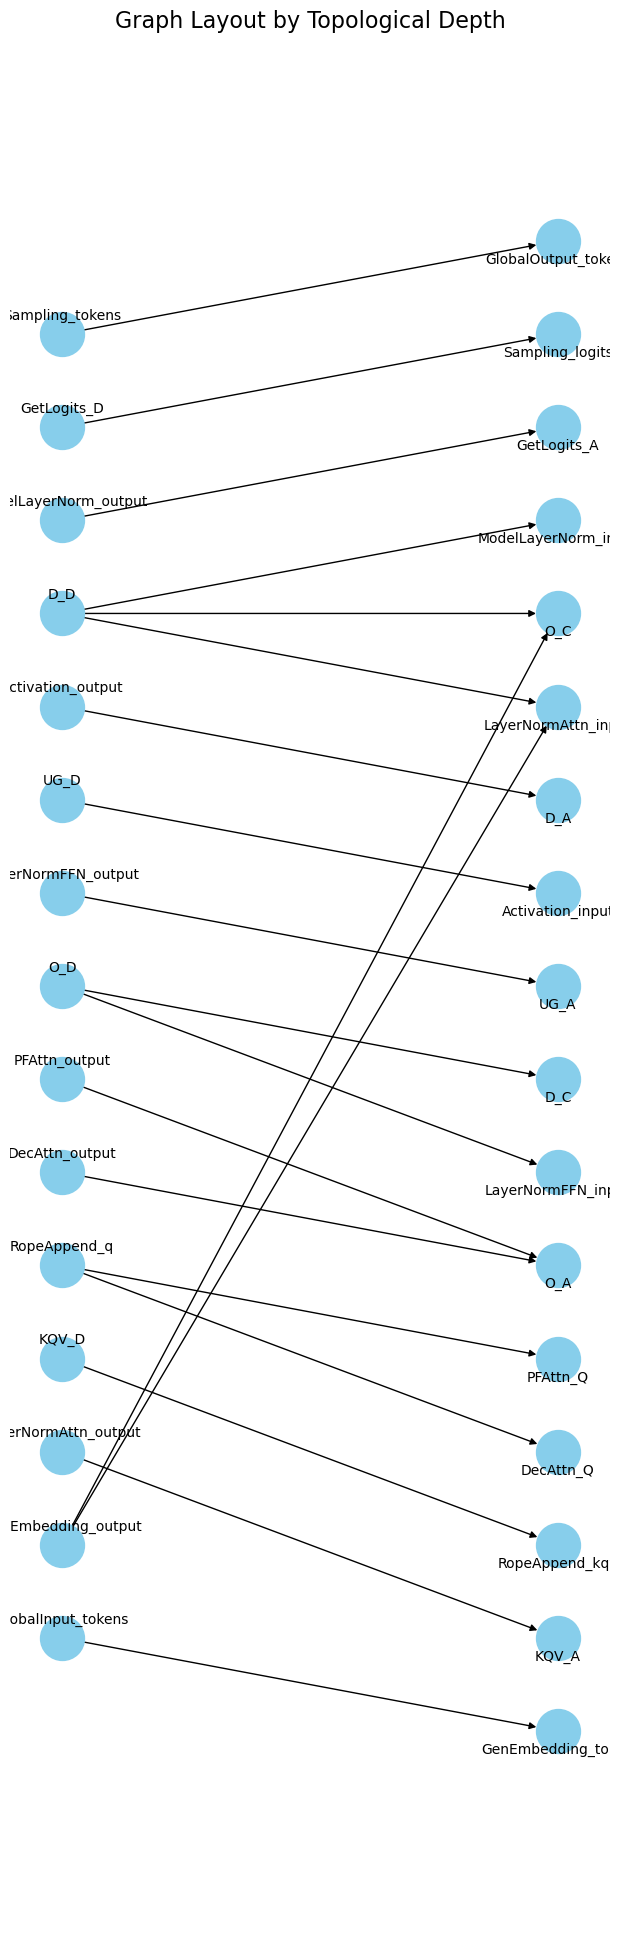

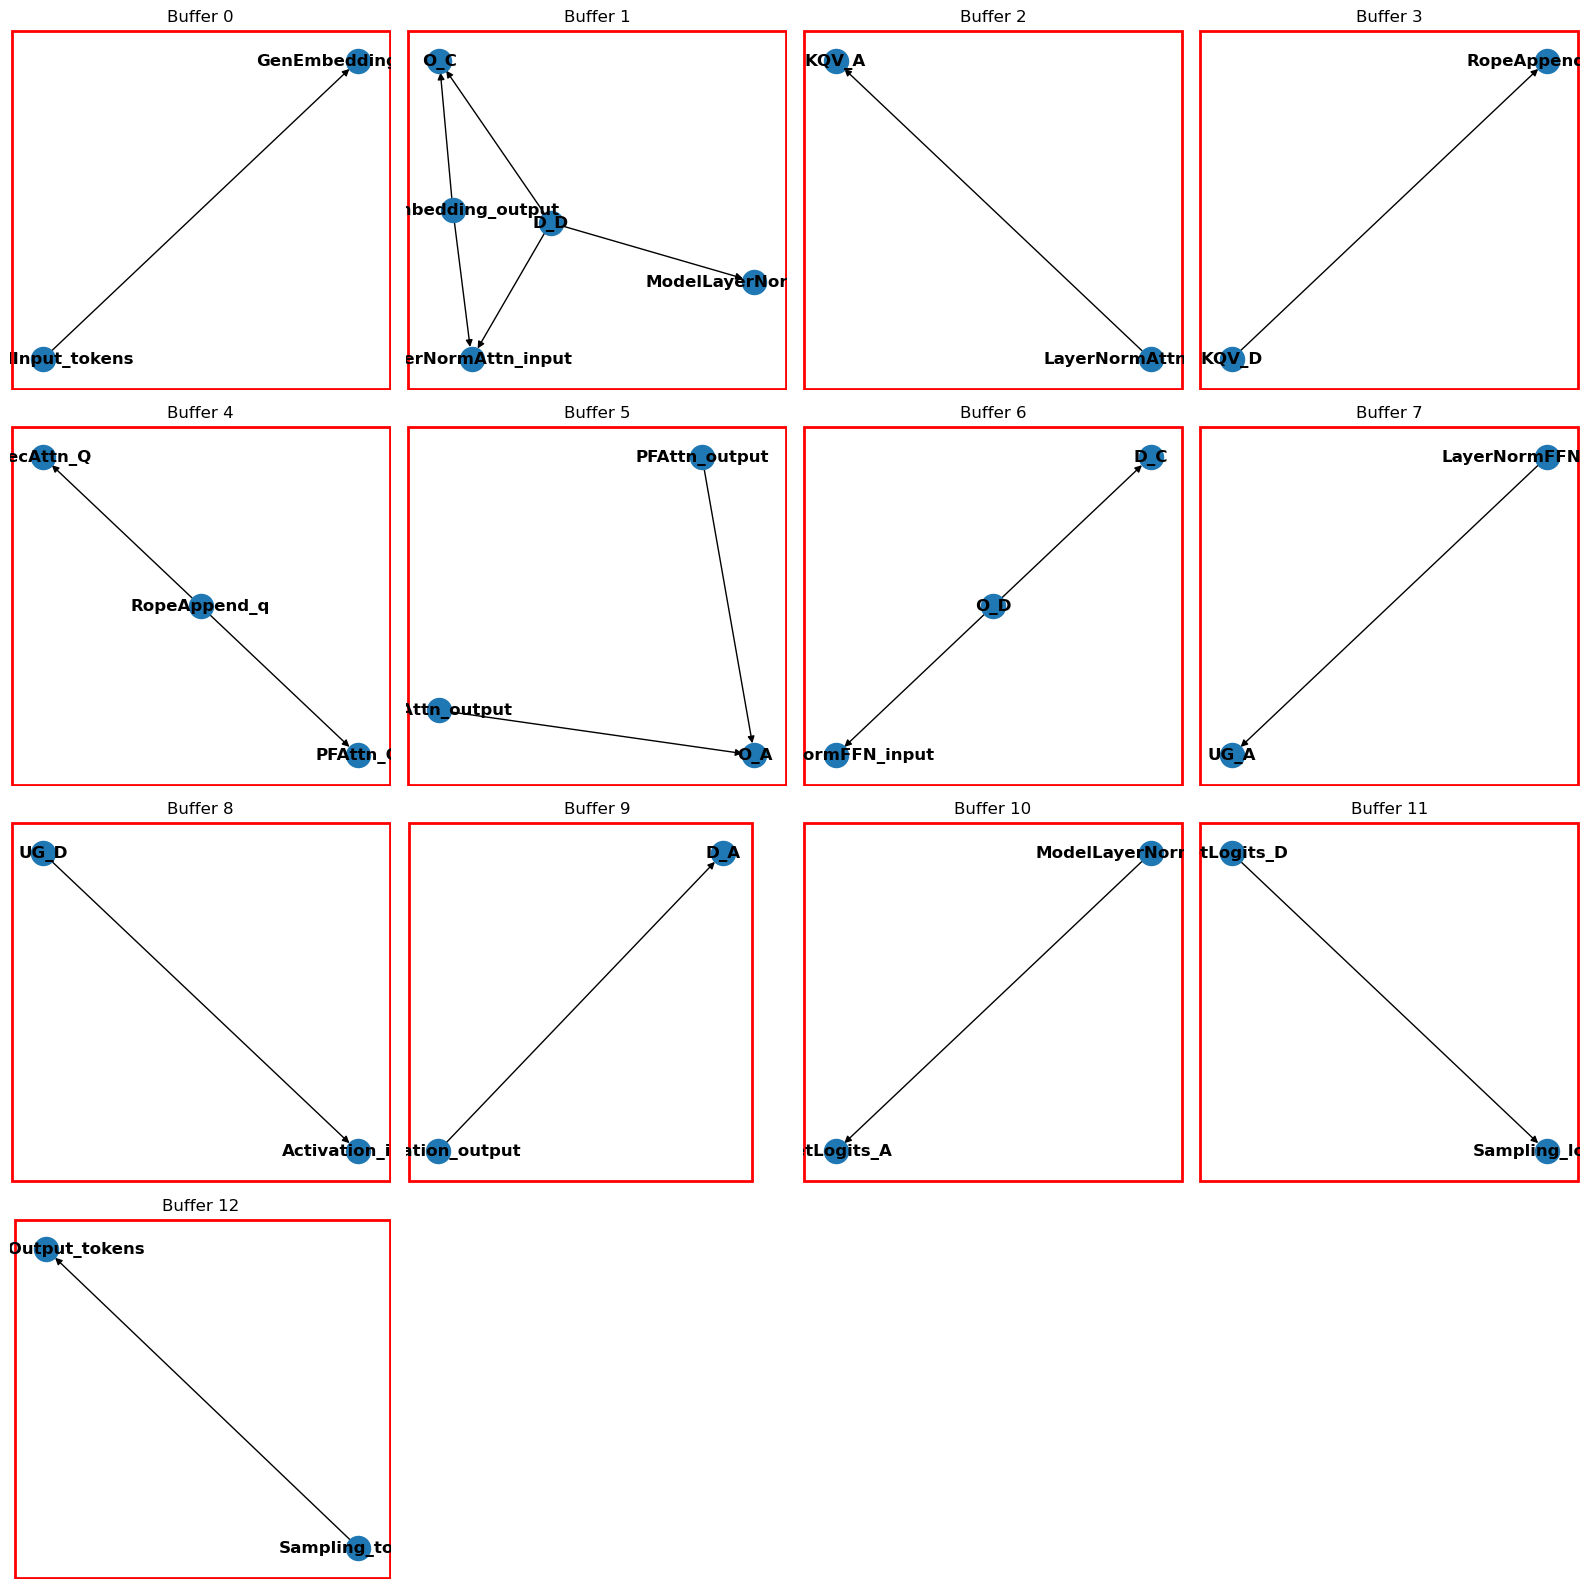

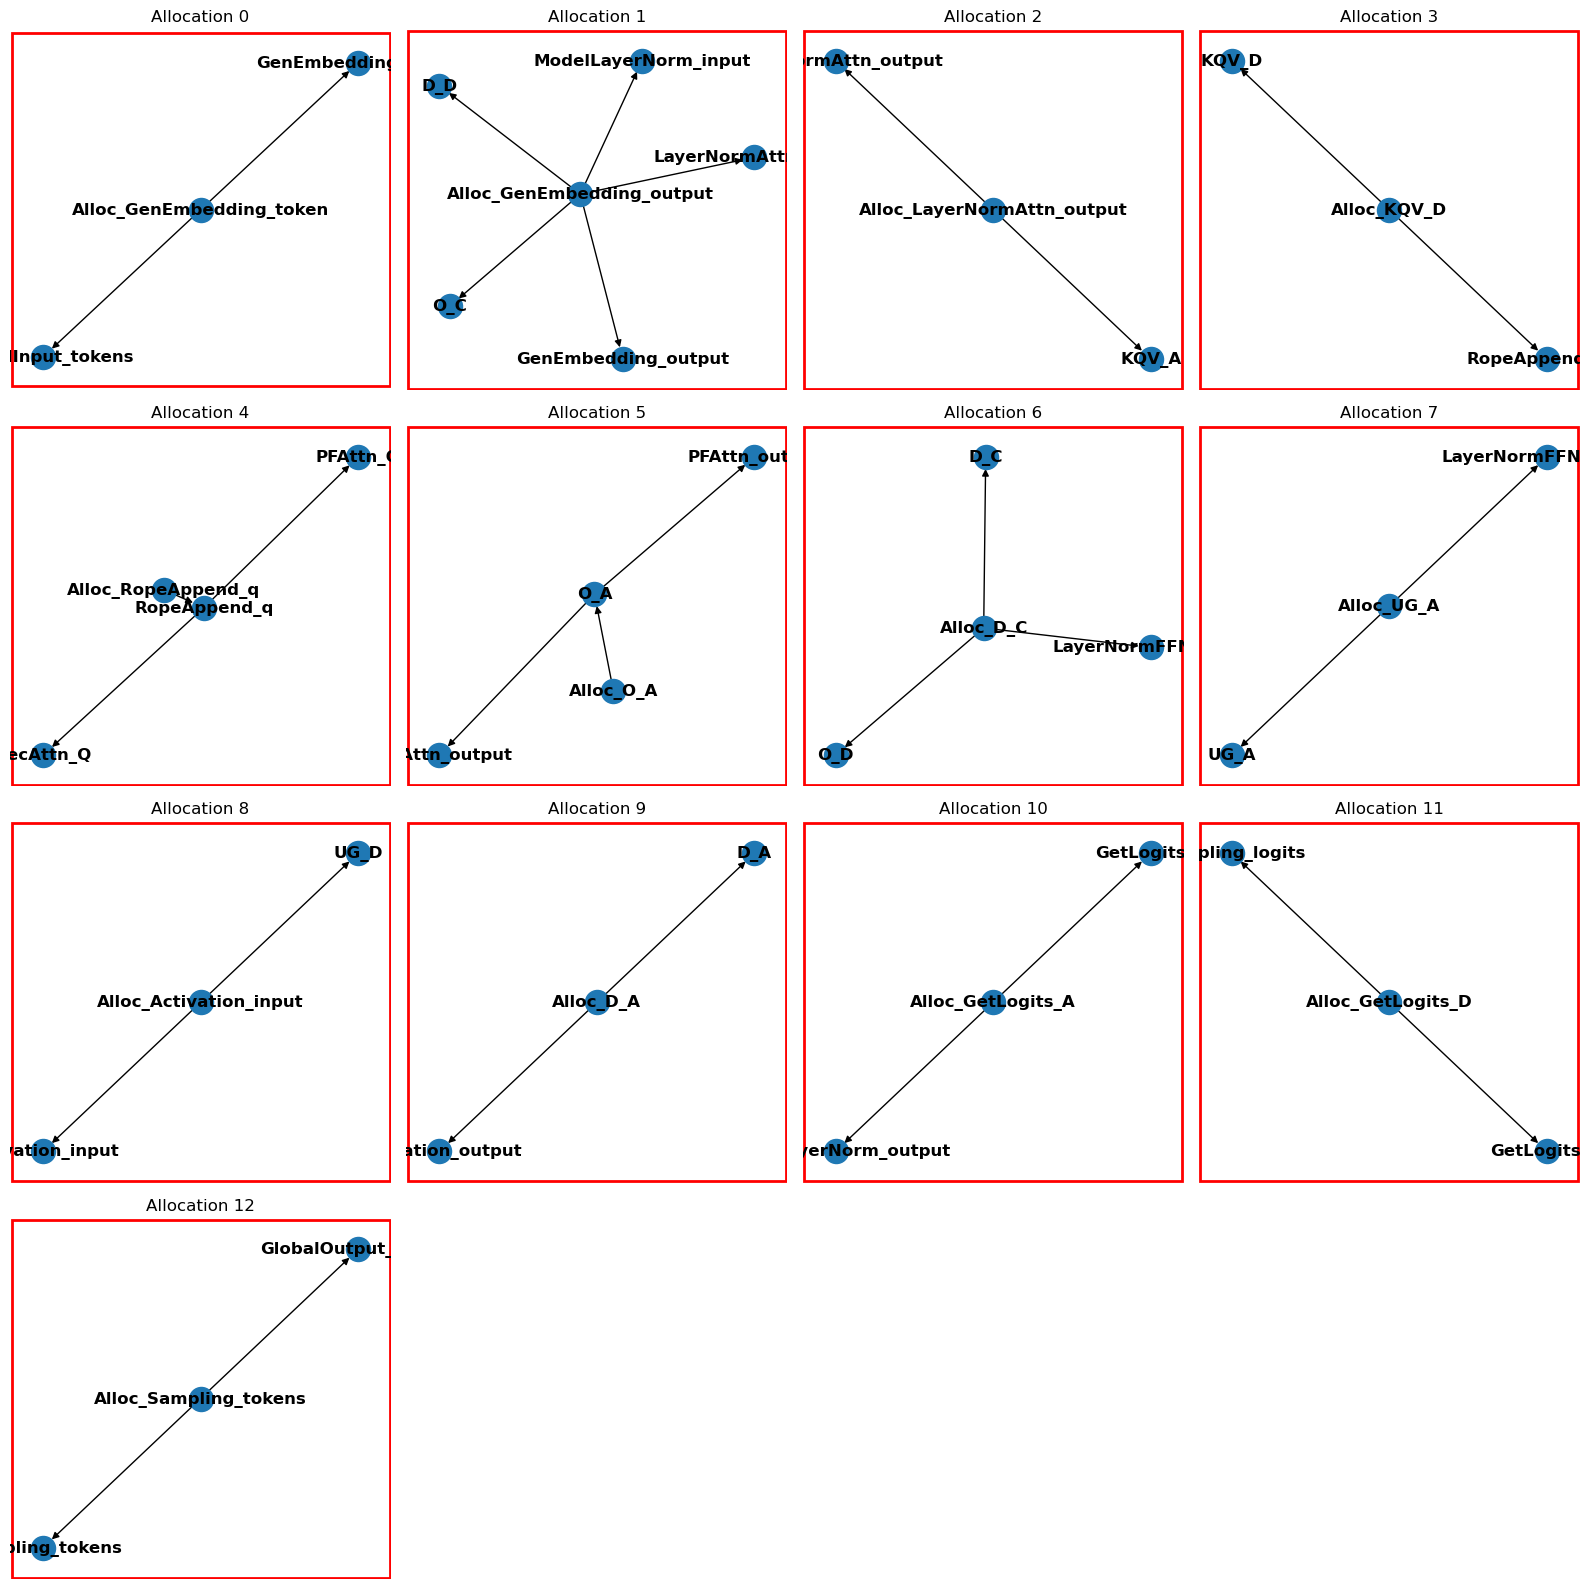

Total allocated: 2.7515182495117188 MB
cumsum_input: tensor([0, 7])
input_tensor: tensor([128000,  13347,     11,    889,    527,    499,     30],
       device='cuda:0', dtype=torch.int32)


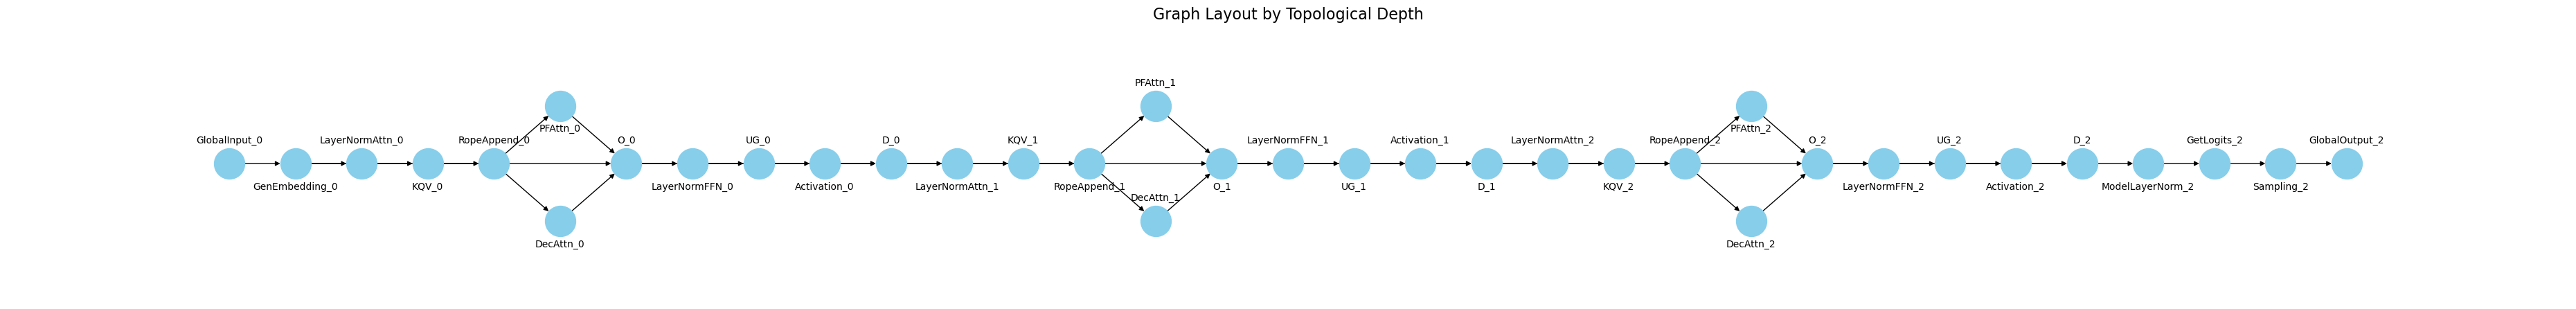

['GlobalInput_0', 'GenEmbedding_0', 'LayerNormAttn_0', 'KQV_0', 'RopeAppend_0', 'DecAttn_0', 'PFAttn_0', 'O_0', 'LayerNormFFN_0', 'UG_0', 'Activation_0', 'D_0', 'LayerNormAttn_1', 'KQV_1', 'RopeAppend_1', 'DecAttn_1', 'PFAttn_1', 'O_1', 'LayerNormFFN_1', 'UG_1', 'Activation_1', 'D_1', 'LayerNormAttn_2', 'KQV_2', 'RopeAppend_2', 'DecAttn_2', 'PFAttn_2', 'O_2', 'LayerNormFFN_2', 'UG_2', 'Activation_2', 'D_2', 'ModelLayerNorm_2', 'GetLogits_2', 'Sampling_2', 'GlobalOutput_2']
GlobalInput_0
GenEmbedding_0
cuda:0
tensor([[-8.2970e-05,  2.5749e-04, -2.4605e-04,  ..., -3.2425e-04,
         -2.1553e-04,  4.7112e-04],
        [ 1.3733e-03, -9.1553e-03,  1.9409e-02,  ...,  4.9744e-03,
          1.8066e-02,  3.0060e-03],
        [-2.5558e-04, -4.1199e-04,  3.6478e-05,  ...,  2.1267e-04,
          3.1471e-05,  2.9182e-04],
        ...,
        [ 3.6621e-03,  7.0572e-04,  1.0071e-03,  ...,  3.0975e-03,
         -1.8692e-04,  7.9346e-03],
        [-6.9275e-03, -4.8523e-03, -2.3193e-03,  ..., -2.6398

RuntimeError: CUDA kernel failed: an illegal memory access was encountered
Exception raised from genEmbeddingLauncher at /code/pllm/compute-bound/python_binding/pybind/bind_genEmbedding.cu:63 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::string) + 0x96 (0x7f06e096c446 in /root/anaconda3/lib/python3.11/site-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::string const&) + 0x64 (0x7f06e09166e4 in /root/anaconda3/lib/python3.11/site-packages/torch/lib/libc10.so)
frame #2: <unknown function> + 0x78c2 (0x7f06e0cdc8c2 in /code/pllm/compute-bound/python_binding/playground/../../build/bind_genEmbedding.cpython-311-x86_64-linux-gnu.so)
frame #3: <unknown function> + 0xbb30 (0x7f06e0ce0b30 in /code/pllm/compute-bound/python_binding/playground/../../build/bind_genEmbedding.cpython-311-x86_64-linux-gnu.so)
frame #4: <unknown function> + 0x13f76 (0x7f06e0ce8f76 in /code/pllm/compute-bound/python_bindin

In [9]:
import transformers
import os
os.environ["HF_HOME"] = "/code/hf"

class Pipeline():
    def __init__(self):
        # Set parameters as instance variables.
        self.num_kv_heads = 8
        self.num_qo_heads = 32
        self.kqv_heads = self.num_qo_heads + 2 * self.num_kv_heads
        self.head_dim = 128
        self.vocab_size = 128256
        self.hidden_dim = 4096
        self.intermediate_dim = 14 * 1024
        self.batch_size = 7
        self.layer = 3

    def init(self, weight_path):
        self.init_external_data()
        self.init_operations()
        self.init_dependency()
        self.init_set_shape()
        self.init_set_weight(weight_path)

    def init_external_data(self):
        self.kv_cache = KVCacheNone()

    def init_operations(self):
        self.global_input    = GlobalInput("GlobalInput").first_only()

        self.gen_embedding   = GenEmbedding("GenEmbedding").setWeightName("model.embed_tokens.weight").first_only()

        self.layerNormAttn   = LayerNorm("LayerNormAttn").setWeightName("model.layers.{layer}.input_layernorm.weight")

        self.kqv             = GEMMCombineWeight("KQV").setWeightName([
            "model.layers.{layer}.self_attn.q_proj.weight",
            "model.layers.{layer}.self_attn.k_proj.weight",
            "model.layers.{layer}.self_attn.v_proj.weight"
        ])

        self.ropeAppend      = RopeAppend("RopeAppend")
        self.ropeAppend.externals["KVCache"] = self.kv_cache

        self.decAttn         = DecAttn("DecAttn")
        self.decAttn.externals["KVCache"] = self.kv_cache

        self.pfAttn          = PFAttn("PFAttn")
        self.pfAttn.externals["KVCache"] = self.kv_cache

        self.o               = GEMM("O").setWeightName("model.layers.{layer}.self_attn.o_proj.weight")

        self.layerNormFFN    = LayerNorm("LayerNormFFN").setWeightName("model.layers.{layer}.post_attention_layernorm.weight")

        self.ug              = GEMMCombineWeight("UG").setWeightName([
            "model.layers.{layer}.mlp.up_proj.weight",
            "model.layers.{layer}.mlp.gate_proj.weight"
        ])

        self.activation      = Activation("Activation")

        self.d               = GEMM("D").setWeightName("model.layers.{layer}.mlp.down_proj.weight")

        self.getLogits       = GEMMNoBias("GetLogits").setWeightName("lm_head.weight")
        self.getLogits.last_layer_only = True

        self.modelLayerNorm  = LayerNorm("ModelLayerNorm").setWeightName("model.norm.weight")
        self.modelLayerNorm.last_layer_only = True

        self.sample          = Sampling("Sampling")
        self.sample.last_layer_only = True

        self.global_output   = GlobalOutput("GlobalOutput")
        self.global_output.last_layer_only = True

        # Save operations in an instance variable.
        self.operation_list = [
            self.global_input, self.gen_embedding, self.layerNormAttn, self.kqv, self.ropeAppend,
            self.decAttn, self.pfAttn, self.o, self.layerNormFFN, self.ug, self.activation, self.d,
            self.modelLayerNorm, self.getLogits, self.sample, self.global_output
        ]
    
    def init_dependency(self):
        self.global_input.outputs["tokens"] >> self.gen_embedding.inputs["token"]

        self.gen_embedding.outputs["output"] >> self.layerNormAttn.inputs["input"]

        self.layerNormAttn.outputs["output"] >> self.kqv.inputs["A"]

        self.kqv.outputs["D"] >> self.ropeAppend.inputs["kqv"]

        self.ropeAppend.outputs["q"] >> self.decAttn.inputs["Q"]
        self.ropeAppend.outputs["q"] >> self.pfAttn.inputs["Q"]

        self.decAttn.outputs["output"] >> self.o.inputs["A"]
        self.pfAttn.outputs["output"] >> self.o.inputs["A"]
        self.gen_embedding.outputs["output"] >> self.o.inputs["C"]

        self.o.outputs["D"] >> self.layerNormFFN.inputs["input"]

        self.layerNormFFN.outputs["output"] >> self.ug.inputs["A"]

        self.ug.outputs["D"] >> self.activation.inputs["input"]

        self.activation.outputs["output"] >> self.d.inputs["A"]

        self.o.outputs["D"] >> self.d.inputs["C"]
        # Additional dependency: d feeds back to layerNormAttn and o.inputs["C"]
        self.d.outputs["D"].chain(self.layerNormAttn.inputs["input"], True)
        self.d.outputs["D"].chain(self.o.inputs["C"], True)
        self.d.outputs["D"] >> self.modelLayerNorm.inputs["input"]

        self.modelLayerNorm.outputs["output"] >> self.getLogits.inputs["A"]

        self.getLogits.outputs["D"] >> self.sample.inputs["logits"]

        self.sample.outputs["tokens"] >> self.global_output.inputs["tokens"]
        
        for operation in self.operation_list:
            operation.checkConnection()
    
    def init_set_shape(self):
        self.gen_embedding.setShape(self.hidden_dim, self.vocab_size)
        self.layerNormAttn.setShape(self.hidden_dim)
        self.kqv.setShape(self.kqv_heads * self.head_dim, self.hidden_dim)
        self.decAttn.setShape(self.num_kv_heads, self.num_qo_heads, self.head_dim)
        self.pfAttn.setShape(self.num_kv_heads, self.num_qo_heads, self.head_dim)
        self.ropeAppend.setShape(self.num_kv_heads, self.num_qo_heads, self.head_dim)
        self.o.setShape(self.hidden_dim, self.hidden_dim)
        self.layerNormFFN.setShape(self.hidden_dim)
        self.ug.setShape(self.intermediate_dim * 2, self.hidden_dim)
        self.d.setShape(self.hidden_dim, self.intermediate_dim)
        self.activation.setShape(self.intermediate_dim)
        self.modelLayerNorm.setShape(self.hidden_dim)
        self.getLogits.setShape(self.vocab_size, self.hidden_dim)
        self.sample.setShape(self.vocab_size)
    
    def init_set_weight(self, weight_path):
        weight_manager = WeightManager()
        weight_manager.load_from_safe_tensor(weight_path)
        weight_manager.set_weight(self.operation_list, self.layer)
    
    def config_batch_size(self):
        self.gen_embedding.setBatchSize(self.batch_size)
        self.layerNormAttn.setBatchSize(self.batch_size)
        self.kqv.setBatchSize(self.batch_size)
        self.decAttn.setBatchSize(0)
        self.pfAttn.setBatchSize(self.batch_size)
        self.ropeAppend.setBatchSize(self.batch_size)
        self.layerNormFFN.setBatchSize(self.batch_size)
        self.ug.setBatchSize(self.batch_size)
        self.activation.setBatchSize(self.batch_size)
        self.o.setBatchSize(self.batch_size)
        self.d.setBatchSize(self.batch_size)
        self.modelLayerNorm.setBatchSize(self.batch_size)
        self.getLogits.setBatchSize(self.batch_size)
        self.sample.setBatchSize(self.batch_size)
        self.global_input.setBatchSize(self.batch_size)
        self.global_output.setBatchSize(self.batch_size)
    
    def config_algorithm(self):
        pass

    def config(self):
        self.config_batch_size()
        self.config_algorithm()
    
    def update(self, input_ids):
        
        self.update_allocate_buffers()
        # concatenate input_ids into a single tensor
        flattened = [item for sublist in input_ids for item in sublist]
        input_tensor = torch.tensor(flattened, dtype=torch.int32, device='cuda')
        # get cumulative sum of the number of tokens in each input
        request_length = torch.tensor([len(x) for x in input_ids], dtype=torch.int32)
        cumsum_input = torch.cat([torch.tensor([0], dtype=torch.int32), torch.cumsum(request_length, dim=0)])
        print(f"cumsum_input: {cumsum_input}")
        print(f"input_tensor: {input_tensor}")
        
        self.global_input.outputs["tokens"].tensor[:input_tensor.shape[0]].copy_(input_tensor)
        self.ropeAppend.update(cumsum_input)
        self.decAttn.update(cumsum_input)
        self.pfAttn.update(cumsum_input)
        

    
    def update_allocate_buffers(self):
        # Build list of buffers.
        buffers_list = []
        for operation in self.operation_list:
            for _, wrapper in operation.inputs.items():
                buffers_list.append(wrapper)
            for _, wrapper in operation.outputs.items():
                buffers_list.append(wrapper)
        # Allocate buffers.
        bufferAllocator = BufferAllocator(buffers_list)
        bufferAllocator.allocate_buffer(plot=True)
        print(f"Total allocated: {bufferAllocator.total_allocated / 1024 / 1024} MB")

    def run(self):
        executor = Executor(self.operation_list, self.layer)
        executor.plan_layer_ordering()
        executor.draw_ordered_graph()
        print(executor.ordered_operations)
        # executor.execute({})
        executor.print_debug("out.txt")


from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct")
input_strings = ["Hi, who are you?"]
input_ids = [tokenizer.encode(s) for s in input_strings]
print(input_ids)

pipeline = Pipeline()
pipeline.init("/code/hf/hub/models--meta-llama--Meta-Llama-3-8B-Instruct/snapshots/5f0b02c75b57c5855da9ae460ce51323ea669d8a")
pipeline.config()
pipeline.update(input_ids)
pipeline.run()



In [ ]:
class NPartitionDistributeGEMM(Operations):
    def __init__(self, name, nranks):
        super().__init__(name)
        self.inputs = {
            "A": IOWrapper(self, 'A', IOBufferType.FULL),
            "C": IOWrapper(self, 'C', IOBufferType.DiscontinousPartition)
        }
        self.outputs = {
            "D": IOWrapper(self, 'D', IOBufferType.DiscontinousPartition)
        }
        self.weights = {
            "B": WeightWrapper()
        }
        self.nranks = nranks
    
    # here refering to the whole tensor shape
    def setShape(self, N, K):
        self.N = N // self.nranks
        if N % self.nranks != 0:
            raise ValueError(f"Number of ranks {self.nranks} does not divide N={N}")
        self.K = K
        self.weights["B"].shape = (self.K, self.N)
        
    def setBatchSize(self, M):
        self.M = M
        self.inputs["A"].shape = (self.M, self.K)
        self.inputs["C"].shape = (self.M, self.N)
        self.outputs["D"].shape = (self.M, self.N)
        
    def run(self, layer, rank):
        A = self.inputs["A"].tensor
        C = self.inputs["C"].tensor
        B = self.weights["B"].weight_map[layer][rank]
        self.outputs["D"].tensor.copy_(A.matmul(B) + C)
        
    def setWeightName(self, name_list):
        # is name list is just a string, then convert it to a list
        if isinstance(name_list, str):
            name_list = [name_list]
        self.weight_name = name_list
        return self
    
    def processWeight(self, global_weight_map, total_layers, cached=False):
        self.weights["B"].weight_map = {}
        for l in range(total_layers):
            all_weight = torch.cat([global_weight_map[name.format(layer=l)].t() for name in self.weight_name], dim=1)
            chunked  = all_weight.chunk(self.nranks, dim=1)
            for t in chunked:
                t = t.contiguous()
            self.weights["B"].weight_map[l] = all_weight.chunk(self.nranks, dim=1)
        return self.weights["B"]
    
class KPartitionDistributeGEMM(Operations):
    def __init__(self, name, nranks):
        super().__init__(name)
        self.inputs = {
            "A": IOWrapper(self, 'A', IOBufferType.DiscontinousPartition),
            "C": IOWrapper(self, 'C', IOBufferType.FULL)
        }
        self.outputs = {
            "D": IOWrapper(self, 'D', IOBufferType.DiscontinousPartition)
        }
        self.weights = {
            "B": WeightWrapper()
        }
        self.nranks = nranks
    
    def setShape(self, N, K):
        self.N = N
        self.K = K // self.nranks
        if K % self.nranks != 0:
            raise ValueError(f"Number of ranks {self.nranks} does not divide K={K}")
        self.weights["B"].shape = (self.K, self.N)
    
    def setBatchSize(self, M):
        self.M = M
        self.inputs["A"].shape = (self.M, self.K)
        self.inputs["C"].shape = (self.M, self.N)
        self.outputs["D"].shape = (self.M, self.N)
    
    def run(self, layer, rank):
        A = self.inputs["A"].tensor
        C = self.inputs["C"].tensor
        B = self.weights["B"].weight_map[layer][rank]
        self.outputs["D"].tensor.copy_(A.matmul(B) + C)
    
    def setWeightName(self, name_list):
        # is name list is just a string, then convert it to a list
        if isinstance(name_list, str):
            name_list = [name_list]
        self.weight_name = name_list
        return self
    
    def processWeight(self, global_weight_map, total_layers, cached=False):
        self.weights["B"].weight_map = {}
        for l in range(total_layers):
            all_weight = torch.cat([global_weight_map[name.format(layer=l)] for name in self.weight_name], dim=0)
            chunked  = all_weight.chunk(self.nranks, dim=0)
            for t in chunked:
                t = t.contiguous()
            self.weights["B"].weight_map[l] = all_weight.chunk(self.nranks, dim=0)
        return self.weights["B"]
    
class AllGather(Operations):
    def __init__(self, name, nranks):
        super().__init__(name)
        self.inputs = {
            "input": IOWrapper(self, 'input', IOBufferType.DiscontinousPartition)
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.FULL)
        }
        self.nranks = nranks
    
    def setShape(self, N):
        self.N = N
        self.inputs["input"].shape = (self.N // self.nranks, self.nranks)
        self.outputs["output"].shape = (self.N,)
    
    def setBatchSize(self, M):
        self.M = M
        self.inputs["input"].shape = (self.M, self.N // self.nranks)
        self.outputs["output"].shape = (self.M, self.N)
    
    def run(self, layer):
        self.outputs["output"].tensor.copy_(self.inputs["input"].tensor.repeat(1, self.nranks))
    
    def processWeight(self, global_weight_map, total_layers, cached=False):
        pass

class AllReduce(Operations):
    def __init__(self, name, nranks):
        super().__init__(name)
        self.inputs = {
            "input": IOWrapper(self, 'input', IOBufferType.FULL)
        }
        self.outputs = {
            "output": IOWrapper(self, 'output', IOBufferType.FULL)
        }
        self.nranks = nranks
    
    def setShape(self, N):
        self.N = N
        self.inputs["input"].shape = (self.N,)
        self.outputs["output"].shape = (self.N,)
    
    def setBatchSize(self, M):
        self.M = M
        self.inputs["input"].shape = (self.M, self.N)
        self.outputs["output"].shape = (self.M, self.N)
    
    def run(self, layer):
        self.outputs["output"].tensor.copy_(self.inputs["input"].tensor.sum(dim=0) / self.nranks)
    
    def processWeight(self, global_weight_map, total_layers, cached=False):
        pass

In [ ]:
from transformers import LlamaForCausalLM